# Healthcare Facility Access and Risk Analysis
## CMS Provider of Services File

**Goal:** Analyze healthcare facility access, ownership mix, certification patterns, capacity, and operational risk using a current CMS provider dataset.

<!-- POWER BI/TABLEAU TALK TRACK: This project is positioned as a healthcare operations and access dashboard for employers, focusing on geography, facility mix, ownership, and risk. -->

## Why This Dataset

- Official CMS healthcare operations data
- Less overused than common heart disease or diabetes datasets
- Good fit for data analyst, BI analyst, healthcare analyst, and consulting portfolios
- Dashboard-friendly fields for geography, facility type, ownership, certification, and risk

<!-- POWER BI/TABLEAU TALK TRACK: I selected a dataset that can support business recommendations, not only prediction metrics. -->

In [1]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 100)
sns.set_theme(style='whitegrid')

output_dir = Path('/content/drive/MyDrive/My DS DA Projects/Healthcare Facility Access and Risk Analysis')
output_dir.mkdir(parents=True, exist_ok=True)

print('All created files will be saved here:', output_dir.resolve())

Mounted at /content/drive
All created files will be saved here: /content/drive/MyDrive/My DS DA Projects/Healthcare Facility Access and Risk Analysis


In [2]:
DATA_API_URL = 'https://data.cms.gov/data-api/v1/dataset/8ba0f9b4-9493-4aa0-9f82-44ea9468d1b5/data'
DATASET_PAGE = 'https://catalog.data.gov/dataset/provider-of-services-file-hospital-non-hospital-facilities'

print('Dataset page:', DATASET_PAGE)
print('CMS API:', DATA_API_URL)

Dataset page: https://catalog.data.gov/dataset/provider-of-services-file-hospital-non-hospital-facilities
CMS API: https://data.cms.gov/data-api/v1/dataset/8ba0f9b4-9493-4aa0-9f82-44ea9468d1b5/data


## Load Data

In [3]:
def load_cms_api(url, page_size=5000):
    frames = []
    offset = 0
    while True:
        chunk = pd.read_json(f'{url}?size={page_size}&offset={offset}')
        if chunk.empty:
            break
        frames.append(chunk)
        offset += page_size
        print(f'Loaded {offset:,}+ rows', end='\r')
        if len(chunk) < page_size:
            break
    print()
    return pd.concat(frames, ignore_index=True)

raw = load_cms_api(DATA_API_URL)
raw.to_csv(output_dir / 'cms_provider_services_raw.csv', index=False)
raw.shape

Loaded 45,000+ rows


(44429, 473)

In [4]:
display(raw.head())

,PRVDR_CTGRY_SBTYP_CD,PRVDR_CTGRY_CD,CHOW_CNT,CHOW_DT,CITY_NAME,ACPTBL_POC_SW,CMPLNC_STUS_CD,SSA_CNTY_CD,CROSS_REF_PROVIDER_NUMBER,CRTFCTN_DT,ELGBLTY_SW,FAC_NAME,INTRMDRY_CARR_CD,MDCD_VNDR_NUM,ORGNL_PRTCPTN_DT,CHOW_PRIOR_DT,INTRMDRY_CARR_PRIOR_CD,PRVDR_NUM,RGN_CD,SKLTN_REC_SW,STATE_CD,SSA_STATE_CD,STATE_RGN_CD,ST_ADR,PHNE_NUM,PGM_TRMNTN_CD,TRMNTN_EXPRTN_DT,CRTFCTN_ACTN_TYPE_CD,GNRL_CNTL_TYPE_CD,ZIP_CD,FIPS_STATE_CD,FIPS_CNTY_CD,CBSA_URBN_RRL_IND,CBSA_CD,ACRDTN_EFCTV_DT,ACRDTN_EXPRTN_DT,ACRDTN_TYPE_CD,TOT_AFLTD_AMBLNC_SRVC_CNT,TOT_AFLTD_ASC_CNT,TOT_COLCTD_HOSP_CNT,TOT_AFLTD_ESRD_CNT,TOT_AFLTD_FQHC_CNT,TOT_AFLTD_HHA_CNT,TOT_AFLTD_HOSPC_CNT,TOT_AFLTD_OPO_CNT,TOT_AFLTD_PRTF_CNT,TOT_AFLTD_RHC_CNT,TOT_AFLTD_SNF_CNT,AFLTD_PRVDR_CNT,RSDNT_PGM_ALPTHC_SW,...,ACTVTY_PROFNL_CNTRCT_CNT,ACTVTY_PROFNL_FLTM_CNT,ACTVTY_PROFNL_PRTM_CNT,RDLGY_TCHNCN_CNT,REG_PHRMCST_CNT,INHLTN_THRPST_CNT,RN_CNT,RN_CNTRCT_CNT,RN_FLTM_CNT,RN_PRTM_CNT,RN_VLNTR_CNT,RN_DRCTR_CNTRCT_CNT,RN_DRCTR_FLTM_CNT,RN_DRCTR_PRTM_CNT,SCL_WORKR_CNT,SCL_WORKR_CNTRCT_CNT,SCL_WORKR_FLTM_CNT,SCL_WORKR_PRTM_CNT,SPCH_PTHLGST_ARNGMT_CNT,SPCH_PTHLGST_CNTRCT_CNT,SPCH_PTHLGST_FLTM_CNT,SPCH_PTHLGST_PRTM_CNT,SPCH_PTHLGST_CNT,SPCH_PTHLGST_AUDLGST_CNT,TCHNCL_STF_NUM,TCHNCN_CNT,THRPTC_RCRTNL_CNTRCT_CNT,THRPTC_RCRTNL_FLTM_CNT,THRPTC_RCRTNL_PRTM_CNT,EMPLEE_CNT,VLNTR_CNT,SBUNIT_CNT,SBUNIT_SW,SBUNIT_OPRTN_SW,DNTL_SRGRY_SW,OTLRYNGLGY_SRGRY_SW,ENDSCPY_SRGRY_SW,OB_GYN_SRGRY_SW,OPTHMLGY_SRGRY_SW,ORTHPDC_SRGRY_SW,OTHR_SRGRY_SW,PAIN_SRGRY_SW,PLSTC_SRGRY_SW,FT_SRGRY_SW,SB_SW,SB_SIZE_CD,TCHNLGST_2_YR_RDLGC_CNT,TCHNLGST_ASCT_DGR_CNT,TCHNLGST_BS_BA_DGR_CNT,DLYS_STN_CNT
0,01,1,1,,DOTHAN,N,B,340,010163,20171005,Y,SOUTHEAST HEALTH MEDICAL CENTER,10111,,19660701,,10111,010001,4,N,AL,1,001,1108 ROSS CLARK CIRCLE,3347938701,0,,8,08,36301,01,069,U,20020,20150507,,3,0,0,0,0,0,0,0,0,0,1,0,1,N,...,,,,48,20,34,521,,,,,,,,,,,,,,,,,6,,,,,,,,,,,,,,,,,,,,,N,,,,,
1,01,1,0,,BRIDGEPORT,N,A,350,,20010316,N,NORTH JACKSON HOSPITAL,00010,,19660701,,,010004,4,N,AL,1,001,47005 U S HIGHWAY 72,2564372101,1,20010831,2,08,35740,01,071,R,99901,20000126,20030126,1,0,0,0,0,0,0,0,0,0,0,0,0,N,...,,,,0,1,2,9,,,,,,,,,,,,,,,,,1,,,,,,,,,,,,,,,,,,,,,N,,,,,
2,01,1,0,,BOAZ,Y,A,470,,20021003,Y,MARSHALL MEDICAL CENTERS SOUTH CAMPUS,10111,,19660701,,00010,010005,4,N,AL,1,001,2505 U S HIGHWAY 431 NORTH,2565938310,0,,5,08,35957,01,095,R,99901,20110423,20140423,1,0,0,0,0,0,0,0,0,0,0,0,0,N,...,,,,0,4.75,12,137,,,,,,,,,,,,,,,,,0,,,,,,,,,,,,,,,,,,,,,N,,,,,
3,01,1,1,20100701,FLORENCE,N,B,380,,20190411,Y,NORTH ALABAMA MEDICAL CENTER,10111,,19660701,,10111,010006,4,N,AL,1,001,1701 VETERANS DRIVE,2566291000,0,,5,04,35630,01,077,U,22520,20100527,,1,0,0,0,0,0,0,0,0,0,0,0,0,N,...,,,,38,14,9,415,,,,,,,,,,,,,,,,,1,,,,,,,,,,,,,,,,,,,,,N,,,,,
4,01,1,0,,OPP,N,B,190,,20241212,Y,MIZELL MEMORIAL HOSPITAL,00010,,19660701,,00010,010007,4,N,AL,1,001,702 N MAIN ST,3344933541,0,,2,02,36467,01,039,R,99901,,,0,0,0,0,0,0,1,0,0,0,0,0,1,N,...,,,,9,2,5,38,,,,,,,,,,,,,,,,,1,,,,,,,,,,,,,,,,,,,,,Y,2,,,,


<!-- INSIGHT CELL: Raw dataset value -->

- The raw CMS file contains **44,429 provider records** across **473 original fields**, which makes it much richer than a typical beginner healthcare dataset.
- Because this is official CMS provider data, it is useful for healthcare operations, network planning, compliance review, and market access analysis.
- The raw file is wide and code-heavy, so the main analytical value comes from turning it into a cleaner dashboard-ready table with business-friendly labels.

## Clean and Prepare Dashboard Table

In [5]:
CATEGORY_MAP = {
    '01': 'Hospital',
    '02': 'Skilled Nursing Facility',
    '03': 'Home Health Agency',
    '04': 'Religious Nonmedical Health Care Institution',
    '05': 'Ambulatory Surgical Center',
    '06': 'Hospice',
    '07': 'Clinic',
    '08': 'Other',
    '09': 'End Stage Renal Disease Facility'
}

OWNERSHIP_MAP = {
    '01': 'Voluntary Nonprofit - Church',
    '02': 'Voluntary Nonprofit - Other',
    '03': 'Proprietary - Individual',
    '04': 'Proprietary - Corporation',
    '05': 'Proprietary - Partnership',
    '06': 'Government - Federal',
    '07': 'Government - State',
    '08': 'Government - Local',
    '09': 'Government - Hospital District',
    '10': 'Other'
}

COMPLIANCE_MAP = {
    'A': 'Acceptable',
    'B': 'Acceptable Plan of Correction',
    'C': 'Condition-level Deficiency',
    'D': 'Immediate Jeopardy',
    'E': 'Terminated/Closed'
}

def first_existing_column(dataframe, possible_names):
    for name in possible_names:
        if name in dataframe.columns:
            return name
    return None

def safe_series(dataframe, column_name, default=pd.NA):
    if column_name and column_name in dataframe.columns:
        return dataframe[column_name]
    return pd.Series(default, index=dataframe.index)

def clean_code(series, width=2):
    return (
        series
        .astype('string')
        .str.strip()
        .str.extract(r'(\d+)', expand=False)
        .str.zfill(width)
    )

df = raw.copy()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = (
            df[col]
            .astype('string')
            .str.strip()
            .replace({'': pd.NA, 'nan': pd.NA, 'None': pd.NA})
        )

for col in ['CRTFCTN_DT', 'ORGNL_PRTCPTN_DT', 'TRMNTN_EXPRTN_DT', 'CHOW_DT']:
    if col in df.columns:
        df[col] = pd.to_datetime(
            df[col].astype('string').str.strip(),
            format='%Y%m%d',
            errors='coerce'
        )

for col in ['BED_CNT', 'ZIP_CD', 'PRVDR_CTGRY_CD', 'PRVDR_CTGRY_SBTYP_CD']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

category_col = first_existing_column(df, ['PRVDR_CTGRY_CD', 'PRVDR_CTGRY_SBTYP_CD'])
ownership_col = first_existing_column(df, ['GNRC_CNTL_TYPE_CD', 'GNRL_CNTL_TYPE_CD', 'GNRC_CNTL_CD', 'GNRL_CNTL_CD'])
compliance_col = first_existing_column(df, ['CMPLNC_STUS_CD', 'COMPLIANCE_STATUS_CODE'])

cat_code = clean_code(safe_series(df, category_col), width=2)
ownership_code = clean_code(safe_series(df, ownership_col), width=2)
compliance_code = safe_series(df, compliance_col).astype('string').str.strip()

dashboard_df = pd.DataFrame({
    'Provider Number': safe_series(df, 'PRVDR_NUM'),
    'Facility Name': safe_series(df, 'FAC_NAME'),
    'State': safe_series(df, 'STATE_CD'),
    'City': safe_series(df, 'CITY_NAME'),
    'Zip Code': safe_series(df, 'ZIP_CD'),
    'Region': safe_series(df, 'RGN_CD'),
    'Facility Category Code': cat_code,
    'Facility Category': cat_code.map(CATEGORY_MAP).fillna('Unmapped / Other'),
    'Ownership Code': ownership_code,
    'Ownership Type': ownership_code.map(OWNERSHIP_MAP).fillna('Unmapped / Unknown'),
    'Compliance Status Code': compliance_code,
    'Compliance Status': compliance_code.map(COMPLIANCE_MAP).fillna('Unmapped / Unknown'),
    'Eligible': safe_series(df, 'ELGBLTY_SW'),
    'Acceptable Plan of Correction': safe_series(df, 'ACPTBL_POC_SW'),
    'Certification Date': safe_series(df, 'CRTFCTN_DT'),
    'Original Participation Date': safe_series(df, 'ORGNL_PRTCPTN_DT'),
    'Termination Date': safe_series(df, 'TRMNTN_EXPRTN_DT'),
    'Bed Count': safe_series(df, 'BED_CNT')
})

dashboard_df['Has Termination Date'] = pd.to_datetime(dashboard_df['Termination Date'], errors='coerce').notna()
dashboard_df['Certification Year'] = pd.to_datetime(dashboard_df['Certification Date'], errors='coerce').dt.year

dashboard_df.to_csv(output_dir / 'cms_provider_services_dashboard_ready.csv', index=False)

print('Ownership column used:', ownership_col)
print('Compliance column used:', compliance_col)
print('Saved:', output_dir / 'cms_provider_services_dashboard_ready.csv')

dashboard_df.shape

Ownership column used: GNRL_CNTL_TYPE_CD
Compliance column used: CMPLNC_STUS_CD
Saved: /content/drive/MyDrive/My DS DA Projects/Healthcare Facility Access and Risk Analysis/cms_provider_services_dashboard_ready.csv


(44429, 20)

<!-- INSIGHT CELL: Cleaning and BI-readiness -->

- The cleaned dashboard table reduces the raw CMS file into **20 practical reporting fields**, including provider, location, facility category, ownership, compliance status, dates, and bed count.
- Code fields were translated into readable labels so a hiring manager or business stakeholder can understand the output without reading the CMS data dictionary.
- The notebook also handles missing ownership/compliance columns safely, which makes the workflow more reliable if CMS changes field names in future releases.

## Data Quality

In [6]:
quality = pd.DataFrame({
    'column': dashboard_df.columns,
    'missing_count': dashboard_df.isna().sum().values,
    'missing_pct': (dashboard_df.isna().mean().values * 100).round(2),
    'unique_values': dashboard_df.nunique(dropna=True).values
}).sort_values('missing_pct', ascending=False)

quality.to_csv(output_dir / 'data_quality_summary.csv', index=False)
display(quality)

,column,missing_count,missing_pct,unique_values
17,Bed Count,30177,67.92,887
16,Termination Date,26250,59.08,6137
10,Compliance Status Code,18045,40.62,2
8,Ownership Code,1279,2.88,10
4,Zip Code,270,0.61,13577
2,State,0,0.00,58
1,Facility Name,0,0.00,36667
0,Provider Number,0,0.00,44429
3,City,0,0.00,7843
6,Facility Category Code,0,0.00,5


<!-- INSIGHT CELL: Data quality -->

- **Bed Count is missing for 67.92% of records**, so capacity analysis should be treated as facility-type dependent rather than universal across all providers.
- **Termination Date is missing for 59.08% of records**, which is expected because not every active provider should have a termination date.
- Core dashboard dimensions such as **Provider Number, Facility Name, State, City, Region, and Facility Category Code have 0% missingness**, so the geographic and provider-count analysis is reliable.

## State-Level Facility Access

In [7]:
state_summary = (
    dashboard_df.groupby('State', dropna=False)
    .agg(
        Facilities=('Provider Number', 'count'),
        Total_Beds=('Bed Count', 'sum'),
        Median_Beds=('Bed Count', 'median'),
        Terminated_Facilities=('Has Termination Date', 'sum')
    )
    .reset_index()
)
state_summary['Termination_Rate'] = state_summary['Terminated_Facilities'] / state_summary['Facilities']
state_summary.to_csv(output_dir / 'state_summary.csv', index=False)
display(state_summary.sort_values('Facilities', ascending=False).head(15))

,State,Facilities,Total_Beds,Median_Beds,Terminated_Facilities,Termination_Rate
49,TX,3852,155987,40.0,2067,0.536604
5,CA,3622,155838,95.0,1194,0.329652
11,FL,2052,103607,94.0,1025,0.499513
17,IL,1702,77377,108.0,706,0.414806
21,LA,1549,41336,36.0,623,0.402195
27,MO,1548,43034,60.0,739,0.477390
43,PA,1517,84476,49.0,686,0.452208
20,KY,1472,26856,41.0,389,0.264266
25,MI,1351,50377,62.0,633,0.468542
40,OH,1282,71704,78.0,415,0.323713


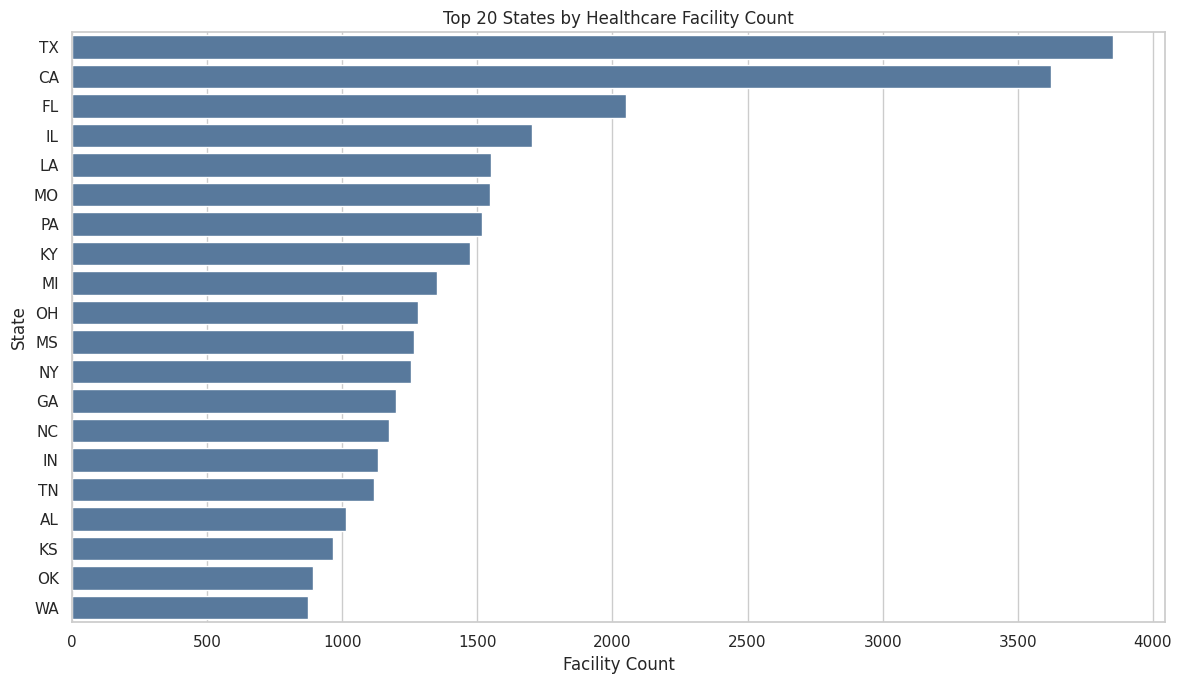

In [8]:
plt.figure(figsize=(12, 7))
plot_data = state_summary.sort_values('Facilities', ascending=False).head(20)
sns.barplot(data=plot_data, x='Facilities', y='State', color='#4c78a8')
plt.title('Top 20 States by Healthcare Facility Count')
plt.xlabel('Facility Count')
plt.ylabel('State')
plt.tight_layout()
plt.show()

<!-- INSIGHT CELL: State-level access -->

- **Texas has the highest facility count with 3,852 providers**, followed by **California with 3,622** and **Florida with 2,052**.
- Texas and California also show the highest total reported bed capacity, each above **155,000 beds**, making them important markets for access and capacity planning.
- The state-level view shows why a dashboard is useful: facility access is highly concentrated, and decision-makers need filters to compare states instead of relying on national totals.

## Facility and Ownership Mix

In [9]:
facility_mix = (
    dashboard_df.groupby('Facility Category')
    .size()
    .reset_index(name='Facilities')
    .sort_values('Facilities', ascending=False)
)

ownership_mix = (
    dashboard_df.groupby('Ownership Type')
    .size()
    .reset_index(name='Facilities')
    .sort_values('Facilities', ascending=False)
)

facility_mix.to_csv(output_dir / 'facility_mix.csv', index=False)
ownership_mix.to_csv(output_dir / 'ownership_mix.csv', index=False)

display(facility_mix)
display(ownership_mix)

,Facility Category,Facilities
2,Unmapped / Other,30170
1,Hospital,13540
0,Hospice,719


,Ownership Type,Facilities
6,Proprietary - Individual,14329
10,Voluntary Nonprofit - Other,11913
9,Voluntary Nonprofit - Church,7105
5,Proprietary - Corporation,5800
8,Unmapped / Unknown,1279
3,Government - State,1113
2,Government - Local,1069
0,Government - Federal,974
7,Proprietary - Partnership,710
1,Government - Hospital District,118


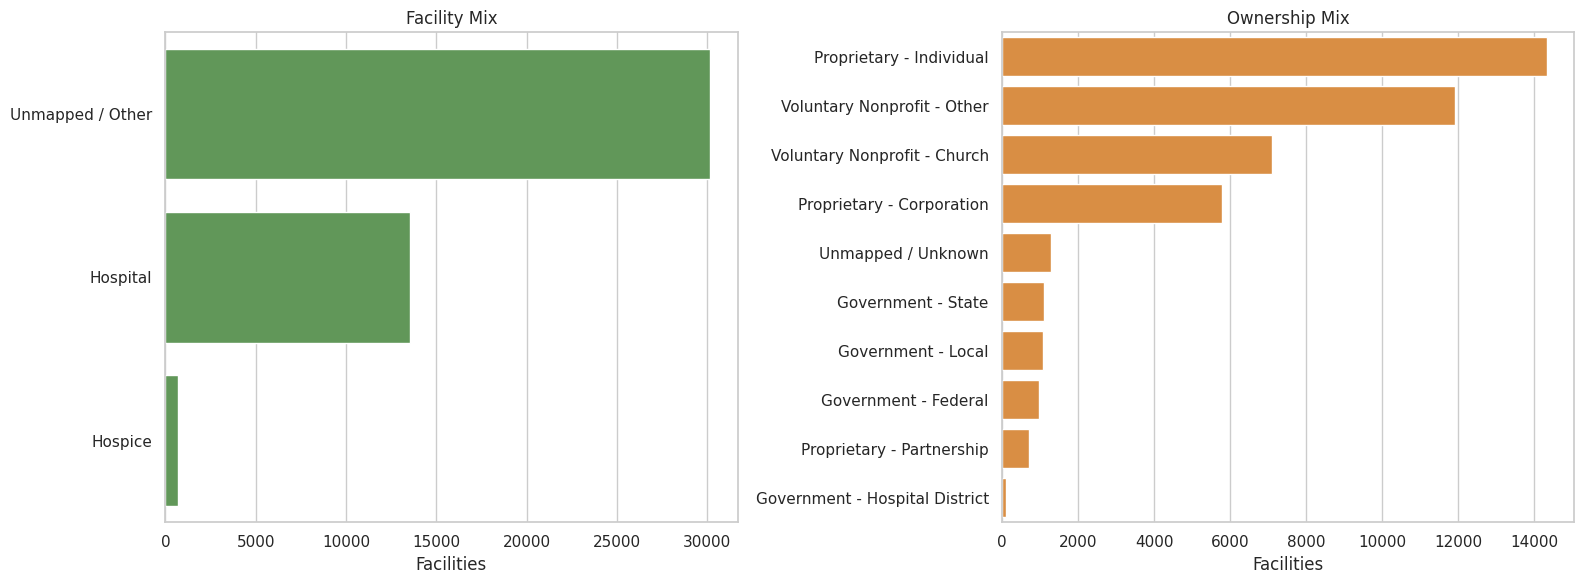

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(data=facility_mix.head(10), x='Facilities', y='Facility Category', ax=axes[0], color='#59a14f')
axes[0].set_title('Facility Mix')
axes[0].set_xlabel('Facilities')
axes[0].set_ylabel('')

sns.barplot(data=ownership_mix.head(10), x='Facilities', y='Ownership Type', ax=axes[1], color='#f28e2b')
axes[1].set_title('Ownership Mix')
axes[1].set_xlabel('Facilities')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

<!-- INSIGHT CELL: Facility and ownership mix -->

- The cleaned category mapping shows **13,540 hospitals** and **719 hospice providers**, while **30,170 records remain unmapped/other**, meaning the project should be transparent about category-code limitations.
- Ownership is more interpretable: the largest groups are **Proprietary - Individual (14,329)**, **Voluntary Nonprofit - Other (11,913)**, **Voluntary Nonprofit - Church (7,105)**, and **Proprietary - Corporation (5,800)**.
- This ownership mix makes the analysis stronger for employers because it connects provider access to business structure, not just counts of facilities.

## Certification and Risk

In [11]:
cert_trend = (
    dashboard_df.dropna(subset=['Certification Year'])
    .groupby('Certification Year')
    .size()
    .reset_index(name='Facilities')
)

cert_trend.to_csv(output_dir / 'certification_year_trend.csv', index=False)
display(cert_trend.tail(20))

,Certification Year,Facilities
29,2007.0,712
30,2008.0,758
31,2009.0,861
32,2010.0,808
33,2011.0,829
34,2012.0,1057
35,2013.0,943
36,2014.0,1237
37,2015.0,1328
38,2016.0,1407


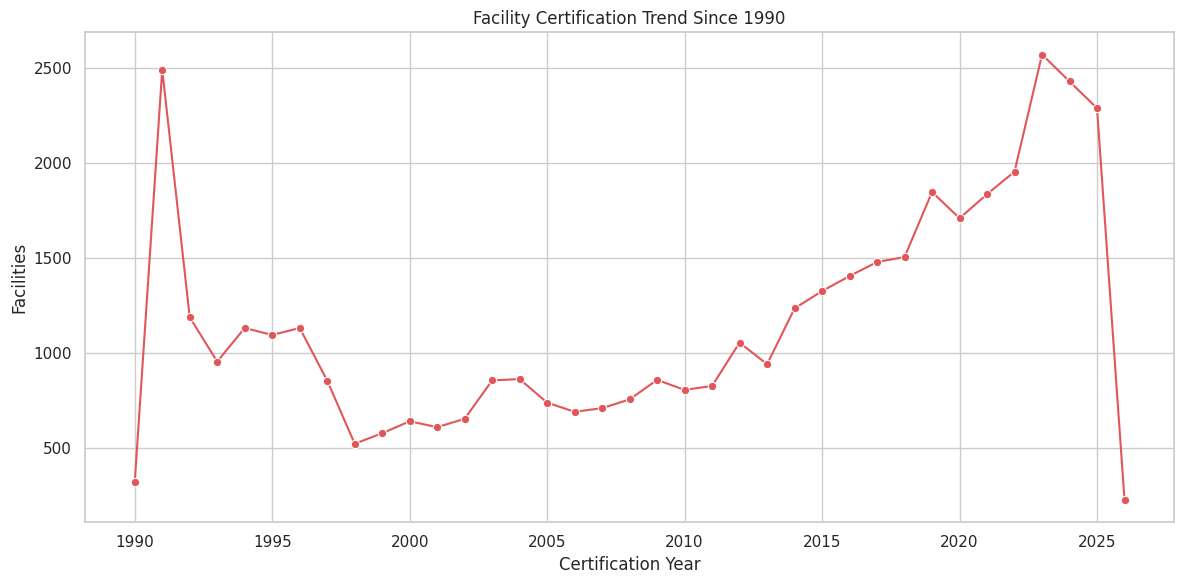

In [12]:
plt.figure(figsize=(12, 6))
plot_data = cert_trend[cert_trend['Certification Year'].between(1990, pd.Timestamp.today().year)]
sns.lineplot(data=plot_data, x='Certification Year', y='Facilities', marker='o', color='#e15759')
plt.title('Facility Certification Trend Since 1990')
plt.xlabel('Certification Year')
plt.ylabel('Facilities')
plt.tight_layout()
plt.show()

<!-- INSIGHT CELL: Certification and risk -->

- Certification activity increased notably in recent years, rising from **1,849 facilities in 2019** to **2,572 in 2023** and **2,431 in 2024**.
- The lower 2026 count should not be interpreted as a decline because the dataset only reflects a partial year.
- Certification year, termination status, and ownership type together create a useful risk-monitoring view for identifying markets that may need closer review.

## Final Insight Sections

<!-- POWER BI TALK TRACK: Use KPI cards for total facilities, states covered, total beds, and termination rate. Use slicers for State, Facility Category, Ownership Type, and Compliance Status. -->
<!-- TABLEAU TALK TRACK: Start with a state map, then use facility mix and ownership views to explain the geography. -->

<!-- INSIGHT CELL: Executive summary -->

- This project analyzed **44,429 CMS provider records** and converted a complex 473-column public dataset into a clean 20-column dashboard-ready file.
- Provider availability is concentrated in large markets, with **Texas, California, and Florida** leading by facility count.
- The strongest business story is healthcare access and provider risk: geography, ownership, certification timing, and capacity all help explain where healthcare networks may be strong or vulnerable.

<!-- INSIGHT CELL: Business recommendation -->

- Healthcare organizations should use this analysis to prioritize deeper review of high-volume states such as Texas, California, and Florida.
- Payers and provider networks can use the dashboard-ready file to compare facility access, ownership structure, reported capacity, and termination indicators by market.
- A strong next step would be to combine this CMS provider file with population, county-level demographics, or health outcome data to measure access gaps more directly.

<!-- INSIGHT CELL: Dashboard plan -->

- **Power BI:** Build an executive monitoring dashboard with KPI cards for total facilities, states covered, total beds, termination rate, and slicers for state, facility category, ownership type, and compliance status.
- **Tableau:** Build a map-first story showing facility concentration by state, then use facility mix and ownership charts to explain what is driving those geographic patterns.
- Both dashboard versions should include a facility-detail table so employers can see that the project supports both high-level strategy and row-level investigation.

In [13]:
# Google Colab: export this notebook to HTML and download it.
from pathlib import Path
from google.colab import files

notebook_path = Path('/content/drive/MyDrive/My DS DA Projects/Healthcare Facility Access and Risk Analysis/cms_provider_services_healthcare_portfolio_analysis.ipynb')
html_path = notebook_path.with_suffix('.html')

!jupyter nbconvert --to html "{notebook_path}"

print('HTML created here:', html_path)
files.download(str(html_path))

[NbConvertApp] Converting notebook /content/drive/MyDrive/My DS DA Projects/Healthcare Facility Access and Risk Analysis/cms_provider_services_healthcare_portfolio_analysis.ipynb to html
[NbConvertApp] Writing 345507 bytes to /content/drive/MyDrive/My DS DA Projects/Healthcare Facility Access and Risk Analysis/cms_provider_services_healthcare_portfolio_analysis.html
HTML created here: /content/drive/MyDrive/My DS DA Projects/Healthcare Facility Access and Risk Analysis/cms_provider_services_healthcare_portfolio_analysis.html


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>